# Absctact

This notebook explores a simple pricing model for online currency exchange platforms. 
We analyze how different pricing margins impact transaction volume and expected profit, demonstrating the trade-off between earning a higher margin per transaction and maintaining a high volume of transactions. 
The notebook uses Python simulations and visualizations to illustrate the Pricing Model, Transaction Volume Model, and Profit Model, providing an intuitive understanding of optimal pricing strategies.

## Introduction

Online currency exchange platforms allow users to convert money between different currencies quickly and conveniently. Unlike banks, these platforms usually operate with relatively small profit margins but handle large transaction volumes.

One of the key decisions for such platforms is how to set buy and sell prices. These prices are typically based on the market exchange rate but include a small margin (spread) that represents the platform’s profit.

There is an important trade-off to consider:

- If the margin is too small, the platform earns very little per transaction.
- If the margin is too large, customers may choose competitors, reducing transaction volume.

The goal of this notebook is to create simple mathematical models that illustrate this relationship. We will use Python simulations to analyze how different pricing margins affect expected profit, covering the Pricing Model, Transaction Volume Model, and Profit Model.

## Pricing Model
**R** be the market exchange rate

**m** be the margin applied by the exchange platform

The platform sets its prices as:

$$
Buy=R(1−m)
$$

$$
Sell=R(1+m)
$$

The spread is the difference between the sell and buy price:

$$
Spread=Sell−Buy
$$

The platform earns money from this spread for every transaction.

## Transaction Volume Model

In reality, customer demand decreases when prices become less competitive.

To represent this behavior, we use a simple linear model:

$$
Volume=BaseVolume×(1−k × m)
$$

Where:

**BaseVolume** is the maximum expected transaction volume

**k** represents customer sensitivity to pricing

**m** is the margin

This is a simplified assumption but it allows us to demonstrate the relationship between pricing and demand.

## Profit Model

The expected profit of the platform can be approximated as:

$$
Profit=Volume×Spread
$$

This model shows the main business trade-off:

Larger spreads increase profit per transaction

But higher spreads reduce transaction volume

The optimal margin is therefore somewhere between these extremes.

## Sumalation idea

To explore how margin affects profit, we simulate the model for a range of margins.

For each margin value we:

1. Calculate the buy and sell prices
2. Estimate the expected transaction volume
3. Calculate the profit

This allows us to show the trade-off between margin size and transaction volume.

## Simulation

In [28]:
!pip install numpy
!pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt

Profit Calculation

In [32]:
def calculate_prices(market_rate, margin):

    buy_price = market_rate * (1 - margin)
    sell_price = market_rate * (1 + margin)
    
    spread = sell_price - buy_price
    
    return buy_price, sell_price, spread

Transaction Volume Function

In [33]:
def calculate_volume(base_volume, sensitivity, margin):
    
    volume = base_volume * (1 - sensitivity * margin)
    
    if volume < 0:
        volume = 0
        
    return volume

Transaction Volume Function

In [ ]:
def calculate_volume(base_volume, sensitivity, margin):
    
    volume = base_volume * (1 - sensitivity * margin)
    
    if volume < 0:
        volume = 0
        
    return volume

Profit calculation

In [ ]:
def calculate_profit(market_rate, margin, base_volume, sensitivity):
    
    buy, sell, spread = calculate_prices(market_rate, margin)
    
    volume = calculate_volume(base_volume, sensitivity, margin)
    
    profit = volume * spread
    
    return profit

Simulation Parameters

In [ ]:
market_rate = 1.95

base_volume = 1_000_000

sensitivity = 20

margins = np.linspace(0.001, 0.02, 50)

Simulation

In [36]:
profits = []

for m in margins:
    
    profit = calculate_profit(
        market_rate,
        m,
        base_volume,
        sensitivity
    )
    
    profits.append(profit)

Profit vs Pricing Margin Plot

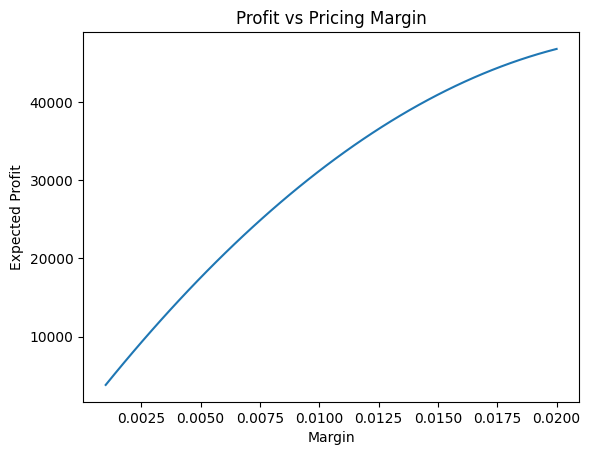

In [44]:
plt.figure()

plt.plot(margins, profits)

plt.xlabel("Margin")
plt.ylabel("Expected Profit")

plt.title("Profit vs Pricing Margin")

plt.show()

We can observe how the expected profit changes as the pricing margin increases:

- At very low margins, the profit is low because the spread between buy and sell prices is minimal.

- As the margin grows, the spread becomes larger, leading to an increase in profit.

- However, after reaching a certain point, profit starts decreasing. This is because the higher margin discourages transactions, reducing the overall volume.

This graph demonstrates the trade-off between margin and volume: you want a margin high enough to earn a good spread, but not so high that you lose too many transactions. The optimal margin is somewhere in the middle, maximizing profit.

In [ ]:
Profit and Transaction Volume vs Margin Plot

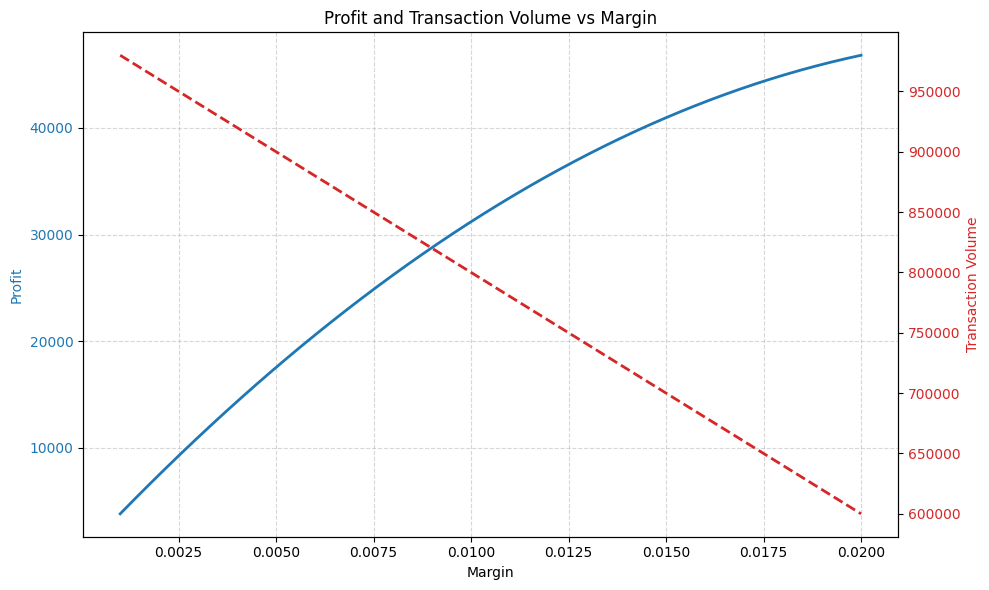

In [43]:
fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:blue'
ax1.set_xlabel('Margin')
ax1.set_ylabel('Profit', color=color)
ax1.plot(margins, profits, color=color, label='Profit', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:red'
volumes = [calculate_volume(base_volume, sensitivity, m) for m in margins]
ax2.set_ylabel('Transaction Volume', color=color)
ax2.plot(margins, volumes, color=color, linestyle='--', label='Volume', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Profit and Transaction Volume vs Margin")
fig.tight_layout()
plt.show()

Here we show both expected profit and transaction volume as functions of the pricing margin:

- **Blue line**: Expected profit

- **Red dashed line**: Transaction volume

At low margins, transaction volume is high, but profit is moderate because the spread is small.

Increasing the margin increases profit at first, while volume begins to decline gradually.

After a certain margin, volume decreases sharply, and this drop outweighs the benefit of a larger spread, causing profit to decline.

By showing both profit and volume, this graph illustrates the interdependency between pricing margin, profit, and transaction volume. It helps identify the margin that maximizes profit without losing too many transactions.

## Results and Observations

The simulations provide insights into the behavior of an online currency exchange platform under different pricing margins.

- **Graph 1 (Profit vs Margin):** Shows that profit initially increases with margin due to a larger spread, but after a certain point, profit decreases because higher margins reduce transaction volume.  
- **Graph 2 (Profit vs Volume and Spread):** Demonstrates how profit depends jointly on both the transaction volume and spread. Maximum profit occurs at a moderate margin where the spread is sufficient, but the volume is not yet too low.  

Overall, these results highlight the trade-off between margin and transaction volume. They provide a quantitative visualization of how different pricing strategies impact expected profit, setting the stage for further analysis in the Conclusion section.

## Limitations

This model is intentionally simplified and does not include several real-world factors such as:
* market volatility
* competition from other platforms
* transaction costs
* hedging strategies
* multiple currency pairs

Despite these simplifications, the model provides a useful demonstration of the relationship between pricing margins, customer demand, and profitability.

## Conclusion

In this project we created a simple mathematical model for pricing and profit in an online currency exchange platform.

The model shows the relationship between three key factors:

- the market exchange rate
- the margin applied by the platform
- the transaction volume

As the margin increases, the spread between buy and sell prices becomes larger, which increases profit per transaction. However, higher margins may also reduce the number of customers willing to trade.

Through simulation we can explore this trade-off and identify margin values that produce higher total profit.

Although this model is simple, it demonstrates how mathematical skills and simulation can help analyze pricing strategies in financial services.